
各参与者 Task 2 交互的SDG数量:
  P01: 4/17 SDGs, 59 total interactions
  P02: 7/17 SDGs, 21 total interactions
  P03: 16/17 SDGs, 50 total interactions
  P04: 17/17 SDGs, 76 total interactions
  P05: 3/17 SDGs, 36 total interactions
  P06: 8/17 SDGs, 75 total interactions
  P07: 16/17 SDGs, 120 total interactions
  P08: 17/17 SDGs, 74 total interactions
  P09: 3/17 SDGs, 24 total interactions

平均覆盖 (Task 2 only): 10.1/17 SDGs

各SDG总交互次数 (Task 2 only):
  SDG 1: 55
  SDG 2: 78
  SDG 3: 58
  SDG 4: 30
  SDG 5: 35
  SDG 6: 15
  SDG 7: 18
  SDG 8: 19
  SDG 9: 37
  SDG 10: 27
  SDG 11: 33
  SDG 12: 9
  SDG 13: 25
  SDG 14: 24
  SDG 15: 26
  SDG 16: 16
  SDG 17: 30


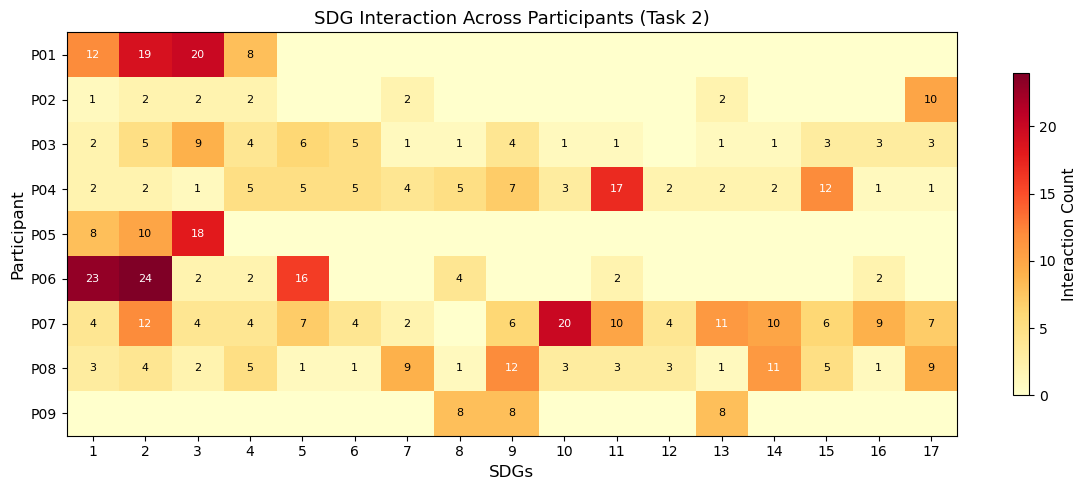

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('P01-P09_merged_log.csv')

# 任务分隔点
SPLIT_POINTS = {
    'P01': 270.95, 'P02': 640.32, 'P03': 637.13, 'P04': 632.38,
    'P05': 843.14, 'P06': 524.88, 'P07': 775.53, 'P08': 290.76,
    'P09': 729.61
}

def get_task(row):
    pid = row['participant_id']
    time = row['time_elapsed_sec']
    split = SPLIT_POINTS[pid]
    if pid == 'P07':
        return 'Task2' if time < split else 'Task1'
    else:
        return 'Task1' if time < split else 'Task2'

df['task'] = df.apply(get_task, axis=1)

# 只取 Task 2 数据
task2 = df[df['task'] == 'Task2']

participants = ['P01','P02','P03','P04','P05','P06','P07','P08','P09']

# 创建 9×17 矩阵
heatmap_data = np.zeros((9, 17))

for i, pid in enumerate(participants):
    pid_data = task2[task2['participant_id']==pid]
    
    # 从 sdg 列获取 (preview, select, deselect)
    sdg_events = pid_data[pid_data['event'].isin(['sdg_preview', 'sdg_select', 'sdg_deselect'])]
    for sdg in sdg_events['sdg'].dropna():
        try:
            sdg_num = int(float(sdg))
            if 1 <= sdg_num <= 17:
                heatmap_data[i, sdg_num-1] += 1
        except:
            pass
    
    # 从 note_add 的 sdgs 列获取
    note_adds = pid_data[pid_data['event']=='note_add']
    for sdgs_str in note_adds['sdgs'].dropna():
        if pd.notna(sdgs_str) and sdgs_str != '':
            for s in str(sdgs_str).split(';'):
                try:
                    sdg_num = int(float(s))
                    if 1 <= sdg_num <= 17:
                        heatmap_data[i, sdg_num-1] += 1
                except:
                    pass

# 统计
print("\n各参与者 Task 2 交互的SDG数量:")
for i, pid in enumerate(participants):
    engaged = np.sum(heatmap_data[i] > 0)
    total = np.sum(heatmap_data[i])
    print(f"  {pid}: {int(engaged)}/17 SDGs, {int(total)} total interactions")

avg_coverage = np.mean([np.sum(heatmap_data[i] > 0) for i in range(9)])
print(f"\n平均覆盖 (Task 2 only): {avg_coverage:.1f}/17 SDGs")

print("\n各SDG总交互次数 (Task 2 only):")
sdg_totals = heatmap_data.sum(axis=0)
for j in range(17):
    if sdg_totals[j] > 0:
        print(f"  SDG {j+1}: {int(sdg_totals[j])}")

# 绘制热力图
fig, ax = plt.subplots(figsize=(12, 5))

# ========== 配色方案在这里调整 ==========
# 常用选项：'YlGnBu', 'Blues', 'Greens', 'Purples', 'OrRd', 'BuPu', 'GnBu', 'viridis', 'plasma'
cmap = 'YlOrRd'
# ========================================

im = ax.imshow(heatmap_data, cmap=cmap, aspect='auto')

ax.set_xticks(range(17))
ax.set_xticklabels([f'{i}' for i in range(1, 18)])
ax.set_yticks(range(9))
ax.set_yticklabels(participants)

ax.set_xlabel('SDGs', fontsize=12)
ax.set_ylabel('Participant', fontsize=12)
ax.set_title('SDG Interaction Across Participants (Task 2)', fontsize=13)

# 添加数值标注
for i in range(9):
    for j in range(17):
        val = int(heatmap_data[i, j])
        if val > 0:
            text_color = 'white' if val > 10 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', color=text_color, fontsize=8)

# 添加颜色条
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Interaction Count', fontsize=11)

plt.tight_layout()
# plt.savefig('heatmap_sdg_engagement_task2.png', dpi=150, bbox_inches='tight')
plt.savefig('heatmap_sdg_engagement_task2.pdf', bbox_inches='tight')
# print("\n热力图已保存: heatmap_sdg_engagement_task2.png / .pdf")

# 显示图片
plt.show()

In [12]:
coverage_per_participant = [np.sum(heatmap_data[i] > 0) for i in range(9)]
print(f"M={np.mean(coverage_per_participant):.1f}, SD={np.std(coverage_per_participant):.1f}")

M=10.1, SD=5.9
